In [81]:

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr

from astropy.io import fits
from astropy.wcs import WCS

In [82]:
SAVE_FIGS = True

L_BOUNDS = [20, 39.2] # degrees
B_BOUNDS = [-1.1, 1.1] # degrees

# LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe

# FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures' # Aimee
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/difference_maps' # Joe


COMAP_ERR = 0.05
EFFELSBERG_ERR = 0.1
GDIGS_ERR = 0.1 # TEMP - CHECK!
NOBEYAMA_ERR = 0.1 # TEMP
PARKES_ERR = 0.1 # TEMP
SINO_GERMAN_ERR = 0.1 # TEMP
AKARI_ERR = 0.1 # TEMP


COMAP_FWHM = 4.5
EFFELSBERG_FWHM = 4.9999
GDIGS_FWHM = 2 # TEMP
NOBEYAMA_FWHM = 4.9999 # TEMP
PARKES_FWHM = 4.9999 # TEMP
SINO_GERMAN_FWHM = 9.9999 # TEMP
AKARI_FWHM = 4.9999 # TEMP


COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}

# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    "Effelsberg 2.73 GHz (5 amin)" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic.fits", 5.7e9] # CHECK GDIGS FREQUENCY
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    "Nobeyama 10.0GHz (5 amin)" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 9.4e9]
    # "Nobeyama 10.0GHz (10 amin)"  : ["NOBEYAMA-10.0GHz-10.0amin.fits", 9.4e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    # "PARKES 5GHz (5')" : ["PARKES-5.0GHz-5.0amin.fits", 5e9], # CORRUPTED
    "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9]
}


SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (10 amin)" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    "Akari 1875 GHz (5 amin)" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    # "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    # "Akari 2143 GHz (5 amin)" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    # "Akari 3333 GHz (5 amin)" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    # "Akari 4615 GHz (5 amin)" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}

AMI_MAPS = {}

BOLOCAM_MAPS = {} # CORRUPTED

CGPS_MAPS = {} # CORRUPTED

CHIPASS_MAPS = {}

IRIS_MAPS = {}

# Main functions

def get_map(path):
    
    # print(f"\nGetting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    if path == f"{MAPS_DIRECTORY}/comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits":
        header['CRVAL2'] += 0.5/60
        # header['LONPOLE'] = 180.0

    wcs = WCS(header)

    return data, header, wcs


def get_map_info(map_title):
    
    if map_title in COMAP_MAPS.keys():
        fname = COMAP_MAPS[map_title][0]
        freq = COMAP_MAPS[map_title][1]
        fwhm = COMAP_FWHM
        err = COMAP_ERR
    elif map_title in EFFELSBERG_MAPS.keys():
        fname = EFFELSBERG_MAPS[map_title][0]
        freq = EFFELSBERG_MAPS[map_title][1]
        fwhm = EFFELSBERG_FWHM
        err = EFFELSBERG_ERR
    elif map_title in GDIGS_MAPS.keys():
        fname = GDIGS_MAPS[map_title][0]
        freq = GDIGS_MAPS[map_title][1]
        fwhm = GDIGS_FWHM
        err = GDIGS_ERR
    elif map_title in NOBEYAMA_MAPS.keys():
        fname = NOBEYAMA_MAPS[map_title][0]
        freq = NOBEYAMA_MAPS[map_title][1]
        fwhm = NOBEYAMA_FWHM # FIND OUT!
        err = NOBEYAMA_ERR # FIND OUT!
    elif map_title in PARKES_MAPS.keys():
        fname = PARKES_MAPS[map_title][0]
        freq = PARKES_MAPS[map_title][1]
        fwhm = PARKES_FWHM # FIND OUT!
        err = PARKES_ERR # FIND OUT!
    elif map_title in SINO_GERMAN_MAPS.keys():
        fname = SINO_GERMAN_MAPS[map_title][0]
        freq = SINO_GERMAN_MAPS[map_title][1]
        fwhm = SINO_GERMAN_FWHM # FIND OUT!
        err = SINO_GERMAN_ERR # FIND OUT!
    elif map_title in AKARI_MAPS.keys():
        fname = AKARI_MAPS[map_title][0]
        freq = AKARI_MAPS[map_title][1]
        fwhm = AKARI_FWHM # FIND OUT!
        err = AKARI_ERR # FIND OUT!
    
    # (ADD MORE MAPS AS NECESSARY)
    
    else:
        print(f'Error extracting map details for {map_title}')
        return None, None, None, None

    return fname, freq, fwhm, err


def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light
    Jy_to_SI = 1e-26

    factor = (c**2) / (2 * k_B * (freq**2)) * Jy_to_SI
    
    return factor * inp


def convert_to_mK(map_title, map, map_freq):
    
    # COMAP and GDIGS in K
    if map_title in COMAP_MAPS.keys():
        map_mK = np.array(map) * 1000 # K to mK
    
    # elif map_title in GDIGS_MAPS.keys():
    #     map_mK = intrrl_to_cont(np.array(map), map_freq, ELECTRON_TEMP) * 1000
    elif map_title in GDIGS_MAPS.keys():
        map_mK = np.array(map) * 1000
    
    # All other maps in Jy/sr (CHECK WHENEVER ADD NEW MAPS!)
    else: 
        map_K = JyPersr_to_K(np.array(map), map_freq) # Jy/sr to K
        map_mK = np.array(map_K) * 1000 # K to mK
    
    return map_mK


def remove_nans(array_of_arrays): # array_of_arrays in form [np.array(a1), np,array(a2), etc.]
    
    mask = np.any([np.isnan(array) for array in array_of_arrays], axis=0)
    
    return tuple(array[~mask] for array in array_of_arrays)


def plot_fits(fits_data, projection, x_coords=[], y_coords=[],
              contour_map=None, n_contours=0, perc_ranges=(0.0, 99.5),
              decorators=None, decorator_locs=None,
              title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    y_poscorr = 0
    x_poscorr = 2
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if contour_map is not None and n_contours > 0:
        levels = np.linspace(np.nanpercentile(contour_map, perc_ranges[0]), np.nanpercentile(contour_map, perc_ranges[1]), n_contours)
        contour_colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
        for lev, col in zip(levels, contour_colors):
            ax.contour(contour_map, levels=[lev], colors=[col], linewidths=0.5)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        x_coords = np.array(x_coords)
        x_coords = remove_nans(np.where((L_BOUNDS[1]<=coord<=L_BOUNDS[0] for coord in x_coords), x_coords, np.nan))
        y_coords = remove_nans(np.where(x_coords==np.nan, y_coords, np.nan))
        ax.plot(x_coords, y_coords, 'rx', markersize=3)

    pix_size = projection.wcs.cdelt[1]
    if decorators is not None and decorator_locs is not None:
        for i, decorator_loc in enumerate(decorator_locs):
            text_x = decorator_loc[0]
            text_y = decorator_loc[1]
            ax.text(text_x+x_poscorr, text_y+y_poscorr, decorators[i], color='white', fontsize=5, bbox=dict(boxstyle='round', facecolor=None, alpha=0.0))
            if i != 0: # Remove first
                ax.axvline(text_x, color='r', linewidth=1.5, linestyle='--')

    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()



def cut_data(data, wcs, header, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS):
    
    lat_min, lat_max = b_bounds[0], b_bounds[1]
    long_min, long_max = l_bounds[0], l_bounds[1]

    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row


    header['CRPIX1'] = wcs.wcs.crpix[0]
    header['CRPIX2'] = wcs.wcs.crpix[1]
    
    return submap, wcs, header


In [83]:
def get_factor(ref_freq, subt_freq, spec_ind):
    return (ref_freq/subt_freq)**(spec_ind)

In [84]:
def galactic_to_pixel(l_coords, b_coords, WCS):

    x_coords = []
    y_coords = []
    for i, _ in enumerate(l_coords):
        l = l_coords[i] 
        b = b_coords[i]
        
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        x_coords.append(x)
        y_coords.append(y)

    return x_coords, y_coords

In [85]:
def find_SNRs(file_path):

    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l = data[:,0]
    b = data[:,1]
    x_radius = data[:,2] / 2
    y_radius = data[:,3] / 3
    
    return l, b, x_radius, y_radius

In [86]:
# map1 - map2
def difference_map(maps, freqs, spec_indices, lin_corrs):
    map1 = maps[0]
    map2 = maps[1]
    factors = []
    for i, spec_index in enumerate(spec_indices):
        factor = get_factor(freqs[0], freqs[1], spec_index)
        factors.append(factor)

    if map1.shape != map2.shape:
        map1col = map1.shape[0]
        map2col = map2.shape[0]
        map1row = map1.shape[1]
        map2row = map2.shape[1]
        map1 = map1[:np.min([map1col,map2col])-1,:np.min([map1row,map2row])-1]
        map2 = map2[:np.min([map1col,map2col])-1,:np.min([map1row,map2row])-1]
    
    diffmap = np.zeros_like(map1)
    map_width = map1.shape[1]
    n_cuts = len(spec_indices)
    lower_indices = []
    upper_indices = []
    for i, factor in enumerate(factors):
        lower_index = int(np.floor(i*map_width/n_cuts))
        upper_index = int(np.floor((i+1)*map_width/n_cuts))
        lower_indices.append(lower_index)
        upper_indices.append(upper_index)
        submap1 = map1[:,lower_index:upper_index]
        submap2 = map1[:,lower_index:upper_index]
        diffmap[:,lower_index:upper_index] = submap1 - factor*submap2 - lin_corrs[i]

    return diffmap, lower_indices, upper_indices

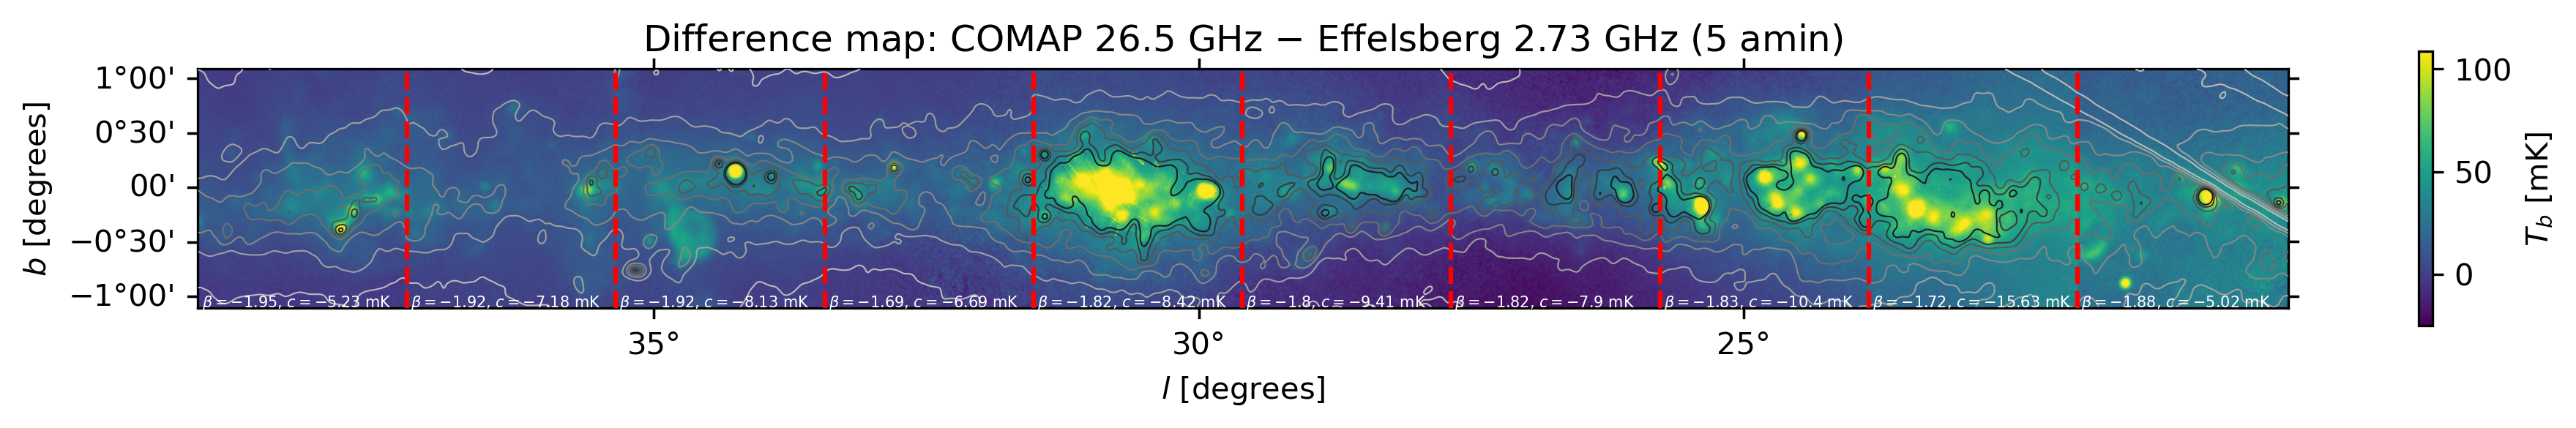

In [87]:
# Subtract subt_map from ref_map

subt_mapname = "Effelsberg 2.73 GHz (5 amin)" # X axis map
ref_mapname = "COMAP 26.5 GHz" # Y axis map
tracer_mapname = "Akari 1875 GHz (5 amin)"

spectral_indices = [-1.95, -1.92, -1.92, -1.69, -1.82, -1.80, -1.82, -1.83, -1.72, -1.88] # Eberg vs COMAP 26.5 GHz

linear_corrections = [-5.23, -7.18, -8.13, -6.69, -8.42, -9.41, -7.90, -10.40, -15.63, -5.02] # Eberg vs COMAP 26.5 GHz

refmap_fname, refmap_freq, refmap_FWHM, refmap_err = get_map_info(ref_mapname)
ref_map, ref_header, ref_wcs = get_map(f"{MAPS_DIRECTORY}/{refmap_fname}")
ref_map, ref_wcs, _ = cut_data(ref_map, ref_wcs, ref_header)
ref_map = convert_to_mK(ref_mapname, ref_map, refmap_freq)

subt_fname, subt_freq, subt_FWHM, subt_err = get_map_info(subt_mapname)
subt_map, subt_header, subt_wcs = get_map(f"{MAPS_DIRECTORY}/{subt_fname}")
subt_map, subt_wcs, _ = cut_data(subt_map, subt_wcs, subt_header)
subt_map = convert_to_mK(subt_mapname, subt_map, subt_freq)

tracermap_fname, tracermap_freq, tracermap_FWHM, tracermap_err = get_map_info(tracer_mapname)
tracer_map, tracer_header, tracer_wcs = get_map(f"{MAPS_DIRECTORY}/{tracermap_fname}")
tracer_map, tracer_wcs, _ = cut_data(tracer_map, tracer_wcs, tracer_header)
tracer_map = convert_to_mK(tracer_mapname, tracer_map, tracermap_freq)

diff_map, text_xs, _ = difference_map((ref_map, subt_map), (refmap_freq, subt_freq), spectral_indices, linear_corrections)


textbox_strs = []
textbox_locs = []
for i, text_x in enumerate(text_xs):
    text_str = ', '.join([
        rf"$\beta = {spectral_indices[i]}$",
        rf"$c = {linear_corrections[i]}$ mK"
        ])
    textbox_strs.append(text_str)
    textbox_locs.append((text_x, 0))

snr_ls, snr_bs, snr_xr, snr_yr = find_SNRs("/home/u20482jg/MPHYS_Project_Local/data/SNRs_final.csv")

snr_ls, snr_bs = galactic_to_pixel(snr_ls, snr_bs, ref_wcs)

plot_fits(diff_map, ref_wcs, x_coords = snr_ls, y_coords = snr_bs,
          contour_map=tracer_map, n_contours=8, perc_ranges=(0.0, 95.0),
          decorators=textbox_strs, decorator_locs=textbox_locs,
          title=f"Difference map: {ref_mapname} $-$ {subt_mapname}")

# levels = [2, 4, 8, 16, 32]
# contour_colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
# for lev, col in zip(levels, contour_colors):
#     ax.contour(mosaic_reprojected, levels=[lev], colors=[col], linewidths=0.5)

In [88]:
print(diff_map.shape)

(131, 1151)
